# Land Cover Suitability Index Analysis for Thailand

This analysis creates a suitability index for renewable energy projects in Thailand by:
1. Loading satellite land cover data
2. Assigning suitability scores based on land cover type and energy source
3. Filtering out restricted areas (protected areas, airports, transmission lines)
4. Outputting the base land cover suitability map for feedstock integration

Existing and committed plant sites are excluded after `11_SI_Farmarea`, once farm/feedstock suitability has been calculated.

## Energy Types Analyzed
- **SI_BGEC**: Biogas/Biomass from Agricultural Crops
- **SI_Biomass**: Biomass Energy
- **SI_Solar**: Solar Energy
- **SI_Wind**: Wind Energy
- **SI_BGWW**: Biogas from Wastewater
- **SI_MSW**: Municipal Solid Waste
- **SI_IEW**: Industrial Effluent Water

## Step 1: Import Required Libraries

Load necessary Python libraries for geospatial analysis and data manipulation.

In [1]:
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import shapely.wkt
import shapely.geometry
import pandas as pd
import shapely.geometry.multipolygon as sh

## Step 2: Create Thailand Boundary

Load Thailand administrative boundary data and define geographic limits for data extraction.

In [2]:
## First, I try to create a boundary of Thailand for acquiring data##
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp')
thailandmap.crs = {'init': 'epsg:4326'}
print(thailandmap.unary_union.bounds)
min_lon = thailandmap.unary_union.bounds[0]
max_lon = thailandmap.unary_union.bounds[2]
max_lat = thailandmap.unary_union.bounds[1]
min_lat = thailandmap.unary_union.bounds[3]

d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\595078\AppData\Local\Temp\ipykernel_2268\3754000212.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  print(thailandmap.unary_union.bounds)


(97.34335847100004, 5.613037873000053, 105.63696451800007, 20.46507381500004)


C:\Users\595078\AppData\Local\Temp\ipykernel_2268\3754000212.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  min_lon = thailandmap.unary_union.bounds[0]
C:\Users\595078\AppData\Local\Temp\ipykernel_2268\3754000212.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  max_lon = thailandmap.unary_union.bounds[2]
C:\Users\595078\AppData\Local\Temp\ipykernel_2268\3754000212.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  max_lat = thailandmap.unary_union.bounds[1]
C:\Users\595078\AppData\Local\Temp\ipykernel_2268\3754000212.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  min_lat = thailandmap.unary_union.bounds[3]


## Step 3: Load Satellite Land Cover Data

Acquire satellite land cover data clipped to Thailand boundaries and prepare it for analysis.

<xarray.Dataset> Size: 192MB
Dimensions:              (lat: 5346, lon: 2985)
Coordinates:
  * lat                  (lat) float64 43kB 5.615 5.618 5.621 ... 20.46 20.46
  * lon                  (lon) float64 24kB 97.35 97.35 97.35 ... 105.6 105.6
Data variables:
    lccs_class           (lat, lon) uint8 16MB ...
    processed_flag       (lat, lon) float32 64MB ...
    current_pixel_state  (lat, lon) float32 64MB ...
    observation_count    (lat, lon) uint16 32MB ...
    change_count         (lat, lon) uint8 16MB ...
    crs                  int32 4B ...
    lat_bounds           (lat) float64 43kB ...
    lon_bounds           (lon) float64 24kB ...
    time_bounds          datetime64[ns] 8B ...
Attributes: (12/38)
    title:                      Land Cover Map of 2022
    summary:                    This dataset characterizes the land cover of ...
    type:                       C3S-LC-L4-LCCS-Map-300m-P1Y
    references:                 https://cds.climate.copernicus.eu/
    institutio

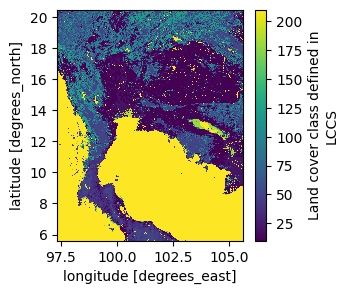

In [3]:
## Then, I acquire data according to the boundary ##
xr_landuse = xr.open_dataset("Data//dataset-satellite-land-cover//C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.nc")
xr_landuse = xr_landuse.sel(lat=slice(min_lat,max_lat), lon=slice(min_lon,max_lon))
xr_landuse = xr_landuse.reindex(lat=xr_landuse.lat[::-1])
xr_landuse = xr_landuse.sel(time = '2022-01-01')
xr_landuse = xr_landuse.drop_vars('time')
xr_landuse = xr_landuse.sel(bounds = 0)
lccs_resolution = 300## meters
print(xr_landuse)
fig, ax = plt.subplots(figsize=(3,3))
xr_landuse['lccs_class'].plot(ax = ax,zorder = 0)

## Step 4: Assign Suitability Scores by Land Cover Type

Calculate suitability indices (0-3 scale) for each energy type based on land cover classes:
- **Score 3**: Highly suitable (grassland, shrubs, bare area)
- **Score 2**: Moderately suitable (agriculture, short vegetation)
- **Score 1**: Low suitability (natural reserves)
- **Score 0**: Not suitable (forest, water, settlements)

In [4]:
## Here, I assign scores to the land according to the literature ##

## Shrubs and Grassland
xr_landuse['SI_BGEC'] = xr.where((xr_landuse['lccs_class'].isin([110,130,120,121,122,200,201,202])),3,0) 
## Short vegetation and agriculture 
xr_landuse['SI_BGEC'] = xr.where((xr_landuse['lccs_class'].isin([140,150,151,152,153,10,11,12,20,30,40])),2,xr_landuse['SI_BGEC'])
## Natural Reserve
xr_landuse['SI_BGEC'] = xr.where((xr_landuse['lccs_class'].isin([180])),1,xr_landuse['SI_BGEC'])
## Tall vegetation, forest,settlement area and water 
xr_landuse['SI_BGEC'] = xr.where((xr_landuse['lccs_class'].isin([50,60,61,62,70,71,72,80,81,82,90,100,160,170,190,210])),0,xr_landuse['SI_BGEC'])

## Shrubs and Grassland
xr_landuse['SI_Biomass'] = xr.where((xr_landuse['lccs_class'].isin([110,130,120,121,122,200,201,202])),3,0) 
## Short vegetation and agriculture 
xr_landuse['SI_Biomass'] = xr.where((xr_landuse['lccs_class'].isin([140,150,151,152,153,10,11,12,20,30,40])),2,xr_landuse['SI_Biomass'])
## Natural Reserve
xr_landuse['SI_Biomass'] = xr.where((xr_landuse['lccs_class'].isin([180])),1,xr_landuse['SI_Biomass'])
## Tall vegetation, forest,settlement area and water 
xr_landuse['SI_Biomass'] = xr.where((xr_landuse['lccs_class'].isin([50,60,61,62,70,71,72,80,81,82,90,100,160,170,190,210])),0,xr_landuse['SI_Biomass'])

## Bare area and Grassland
xr_landuse['SI_Solar'] = xr.where((xr_landuse['lccs_class'].isin([200,201,202,110,130])),3,0) 
## Agriculture
xr_landuse['SI_Solar'] = xr.where((xr_landuse['lccs_class'].isin([10,11,12,20,30,40])),2,xr_landuse['SI_Solar'])
## Short vegetation and shrubs
xr_landuse['SI_Solar'] = xr.where((xr_landuse['lccs_class'].isin([120,121,122,140,150,151,152,153,180])),1,xr_landuse['SI_Solar'])
## Tall vegetation, forest,settlement area and water 
xr_landuse['SI_Solar'] = xr.where((xr_landuse['lccs_class'].isin([50,60,61,62,70,71,72,80,81,82,90,100,160,170,190,210])),0,xr_landuse['SI_Solar'])

## Bare area and Grassland
xr_landuse['SI_Wind'] = xr.where((xr_landuse['lccs_class'].isin([200,201,202,110,130])),3,0) 
## Agriculture
xr_landuse['SI_Wind'] = xr.where((xr_landuse['lccs_class'].isin([10,11,12,20,30,40])),2,xr_landuse['SI_Wind'])
## Short vegetation and shrubs
xr_landuse['SI_Wind'] = xr.where((xr_landuse['lccs_class'].isin([120,121,122,140,150,151,152,153,180])),1,xr_landuse['SI_Wind'])
## Tall vegetation, forest,settlement area and water 
xr_landuse['SI_Wind'] = xr.where((xr_landuse['lccs_class'].isin([50,60,61,62,70,71,72,80,81,82,90,100,160,170,190,210])),0,xr_landuse['SI_Wind'])

## Shrubs and Grassland
xr_landuse['SI_BGWW'] = xr.where((xr_landuse['lccs_class'].isin([110,130,120,121,122,200,201,202])),3,0) 
## Short vegetation and agriculture 
xr_landuse['SI_BGWW'] = xr.where((xr_landuse['lccs_class'].isin([140,150,151,152,153,10,11,12,20,30,40])),2,xr_landuse['SI_BGWW'])
## Natural Reserve
xr_landuse['SI_BGWW'] = xr.where((xr_landuse['lccs_class'].isin([180])),1,xr_landuse['SI_BGWW'])
## Tall vegetation, forest,settlement area and water 
xr_landuse['SI_BGWW'] = xr.where((xr_landuse['lccs_class'].isin([50,60,61,62,70,71,72,80,81,82,90,100,160,170,190,210])),0,xr_landuse['SI_BGWW'])

## Shrubs and Grassland
xr_landuse['SI_MSW'] = xr.where((xr_landuse['lccs_class'].isin([110,130,120,121,122,200,201,202])),3,0) 
## Short vegetation and agriculture 
xr_landuse['SI_MSW'] = xr.where((xr_landuse['lccs_class'].isin([140,150,151,152,153,10,11,12,20,30,40])),2,xr_landuse['SI_MSW'])
## Natural Reserve
xr_landuse['SI_MSW'] = xr.where((xr_landuse['lccs_class'].isin([180])),1,xr_landuse['SI_MSW'])
## Tall vegetation, forest,settlement area and water 
xr_landuse['SI_MSW'] = xr.where((xr_landuse['lccs_class'].isin([50,60,61,62,70,71,72,80,81,82,90,100,160,170,190,210])),0,xr_landuse['SI_MSW'])

## Shrubs and Grassland
xr_landuse['SI_IEW'] = xr.where((xr_landuse['lccs_class'].isin([110,130,120,121,122,200,201,202])),3,0) 
## Short vegetation and agriculture 
xr_landuse['SI_IEW'] = xr.where((xr_landuse['lccs_class'].isin([140,150,151,152,153,10,11,12,20,30,40])),2,xr_landuse['SI_IEW'])
## Natural Reserve
xr_landuse['SI_IEW'] = xr.where((xr_landuse['lccs_class'].isin([180])),1,xr_landuse['SI_IEW'])
## Tall vegetation, forest,settlement area and water 
xr_landuse['SI_IEW'] = xr.where((xr_landuse['lccs_class'].isin([50,60,61,62,70,71,72,80,81,82,90,100,160,170,190,210])),0,xr_landuse['SI_IEW'])

print(xr_landuse)

<xarray.Dataset> Size: 638MB
Dimensions:              (lat: 5346, lon: 2985)
Coordinates:
  * lat                  (lat) float64 43kB 5.615 5.618 5.621 ... 20.46 20.46
  * lon                  (lon) float64 24kB 97.35 97.35 97.35 ... 105.6 105.6
Data variables: (12/16)
    lccs_class           (lat, lon) uint8 16MB 210 210 210 210 ... 40 50 50 50
    processed_flag       (lat, lon) float32 64MB ...
    current_pixel_state  (lat, lon) float32 64MB ...
    observation_count    (lat, lon) uint16 32MB ...
    change_count         (lat, lon) uint8 16MB ...
    crs                  int32 4B ...
    ...                   ...
    SI_Biomass           (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 ... 2 2 2 2 0 0 0
    SI_Solar             (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 ... 2 2 2 2 0 0 0
    SI_Wind              (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 ... 2 2 2 2 0 0 0
    SI_BGWW              (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 ... 2 2 2 2 0 0 0
    SI_MSW               (lat, lon) int32 64MB 0 0

## Step 5: Convert to GeoDataFrame

Transform xarray dataset to GeoDataFrame for spatial operations and filtering.

In [5]:
df_landuse_suitability_index = xr_landuse.to_dataframe()
df_landuse_suitability_index.reset_index(inplace=True)
print('before = ',df_landuse_suitability_index.columns, len(df_landuse_suitability_index))

df_landuse_suitability_index = df_landuse_suitability_index.drop(columns=[
    'processed_flag',
    'current_pixel_state',
    'observation_count',
    'change_count',
    'crs',
    'lat_bounds',
    'lon_bounds',
    'time_bounds',
    ])

df_landuse_suitability_index = gpd.GeoDataFrame(df_landuse_suitability_index, geometry =gpd.points_from_xy(df_landuse_suitability_index['lon'],df_landuse_suitability_index['lat']))
df_landuse_suitability_index.crs = {'init': 'epsg:4326'}

print('after = ',df_landuse_suitability_index.columns, len(df_landuse_suitability_index))

before =  Index(['lat', 'lon', 'lccs_class', 'processed_flag', 'current_pixel_state',
       'observation_count', 'change_count', 'crs', 'lat_bounds', 'lon_bounds',
       'time_bounds', 'SI_BGEC', 'SI_Biomass', 'SI_Solar', 'SI_Wind',
       'SI_BGWW', 'SI_MSW', 'SI_IEW'],
      dtype='object') 15957810
after =  Index(['lat', 'lon', 'lccs_class', 'SI_BGEC', 'SI_Biomass', 'SI_Solar',
       'SI_Wind', 'SI_BGWW', 'SI_MSW', 'SI_IEW', 'geometry'],
      dtype='object') 15957810


d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


## Step 6: Filter Areas Outside Thailand

Exclude data points that fall outside Thailand's administrative boundaries.

In [6]:
## Load Thailand boundary
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp')
thailandmap.crs = {'init': 'epsg:4326'}

## Identify points inside Thailand using sjoin
points_in_thailand = gpd.sjoin(df_landuse_suitability_index, thailandmap, how='left', predicate='within')

## Create mask for points outside Thailand (where index_right is NaN)
outside_mask = points_in_thailand.index_right.isna()

## Set all suitability indices to 0 for points outside Thailand
si_columns = ['lccs_class', 'SI_BGEC', 'SI_Biomass', 'SI_Solar', 'SI_Wind', 'SI_BGWW', 'SI_MSW', 'SI_IEW']
for col in si_columns:
    df_landuse_suitability_index[col] = df_landuse_suitability_index[col].where(~outside_mask, 0)

## Convert to xarray
df_landuse_suitability_index = df_landuse_suitability_index.drop(columns='geometry')
df_landuse_suitability_index = df_landuse_suitability_index.set_index(['lat', 'lon'])
xr_landuse_suitability_index = xr.Dataset.from_dataframe(df_landuse_suitability_index)

print(xr_landuse_suitability_index)

d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


<xarray.Dataset> Size: 463MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    lccs_class  (lat, lon) uint8 16MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


### Visualization: Thailand Suitability Index

Display the suitability map for a selected energy type (BGEC) after Thailand boundary filtering.

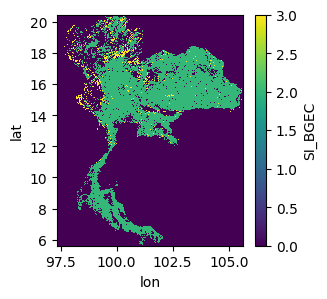

In [7]:
fig, ax = plt.subplots(figsize=(3,3))
xr_landuse_suitability_index['SI_BGEC'].plot(ax = ax,zorder = 0)

## Step 7: Filter Protected Areas

Exclude areas within protected zones (WDPA - World Database on Protected Areas) with a buffer zone.

Loading WDPA protected areas...


d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\595078\AppData\Local\Temp\ipykernel_2268\2117477889.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pta_combined['geometry'] = pta_combined['geometry'].buffer(0.016)


Total protected areas with buffer: 230


d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)



Points inside protected areas: 1849792
<xarray.Dataset> Size: 463MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    lccs_class  (lat, lon) uint8 16MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


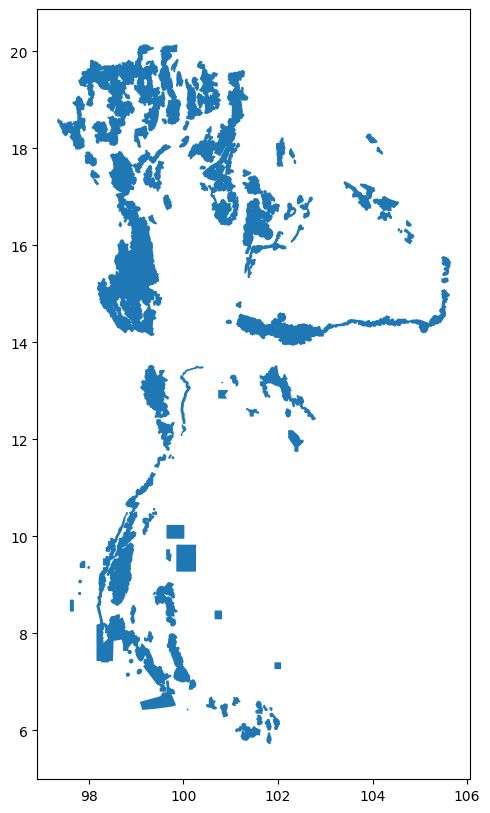

In [8]:
# STEP 7: Filter World Database on Protected Areas (WDPA)
# =========================================================
# Purpose: Exclude areas within protected zones (parks, reserves, sanctuaries)
# These areas are legally protected and not available for energy development
# Note: Protected areas are split across 3 shapefiles (0, 1, 2)

# Load all three WDPA protected area shapefiles
print('Loading WDPA protected areas...')
pta0 = gpd.read_file('Data\\WDPA_WDOECM_Mar2024_Public_THA_shp_0\\WDPA_WDOECM_Mar2024_Public_THA_shp-polygons.shp')
pta1 = gpd.read_file('Data\\WDPA_WDOECM_Mar2024_Public_THA_shp_1\\WDPA_WDOECM_Mar2024_Public_THA_shp-polygons.shp')
pta2 = gpd.read_file('Data\\WDPA_WDOECM_Mar2024_Public_THA_shp_2\\WDPA_WDOECM_Mar2024_Public_THA_shp-polygons.shp')

# Set consistent CRS for all protected area files
for gdf in [pta0, pta1, pta2]:
    gdf.crs = {'init': 'epsg:4326'}

# Combine all three files into single GeoDataFrame for unified analysis
pta_combined = pd.concat([pta0, pta1, pta2], ignore_index=True)
pta_combined = gpd.GeoDataFrame(pta_combined, geometry='geometry', crs={'init': 'epsg:4326'})

# Add buffer zone (0.016 degrees ≈ 1.8 km at equator)
# This creates exclusion zone around protected areas
pta_combined['geometry'] = pta_combined['geometry'].buffer(0.016)

# Visualization and summary
pta_combined.plot(figsize=(10,10))
print(f'Total protected areas with buffer: {len(pta_combined)}')

# Convert xarray back to GeoDataFrame for spatial operations
df_landuse_suitability_index = xr_landuse_suitability_index.to_dataframe()
df_landuse_suitability_index.reset_index(inplace=True)
df_landuse_suitability_index = gpd.GeoDataFrame(
    df_landuse_suitability_index,
    geometry=gpd.points_from_xy(df_landuse_suitability_index['lon'], df_landuse_suitability_index['lat'])
)
df_landuse_suitability_index.crs = {'init': 'epsg:4326'}

# Spatial join: Identify data points within protected areas + buffer
points_in_pta = gpd.sjoin(df_landuse_suitability_index, pta_combined, how='left')

# Create boolean mask: True for points INSIDE protected areas (index_right is NOT NaN)
# Use groupby to handle duplicate indices from sjoin (point in multiple protected areas)
inside_pta_mask = points_in_pta.index_right.notna().groupby(level=0).any()
print(f'\nPoints inside protected areas: {inside_pta_mask.sum()}')


si_columns = ['lccs_class', 'SI_BGEC', 'SI_Biomass', 'SI_Solar', 'SI_Wind', 'SI_BGWW', 'SI_MSW', 'SI_IEW']
for col in si_columns:
    df_landuse_suitability_index[col] = df_landuse_suitability_index[col].where(~inside_pta_mask, 0)

df_landuse_suitability_index = df_landuse_suitability_index.drop(columns='geometry')
df_landuse_suitability_index = df_landuse_suitability_index.set_index(['lat', 'lon'])
xr_landuse_suitability_index = xr.Dataset.from_dataframe(df_landuse_suitability_index)

print(xr_landuse_suitability_index)

### Visualization: After Protected Area Filtering

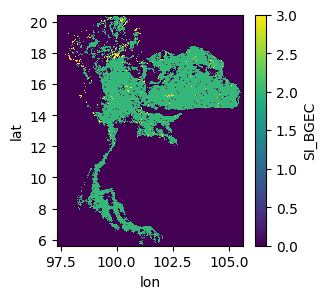

In [9]:
fig, ax = plt.subplots(figsize=(3,3))
xr_landuse_suitability_index['SI_BGEC'].plot(ax = ax,zorder = 0)

## Step 8: Apply Transportation Network Buffer

Exclude areas within a distance buffer of roads (2x resolution), as they are unsuitable for RE development.

Loading transportation network...


d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


Computing distances to nearest road...
Points too close to roads (<600m): 2245072
<xarray.Dataset> Size: 463MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    lccs_class  (lat, lon) uint8 16MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


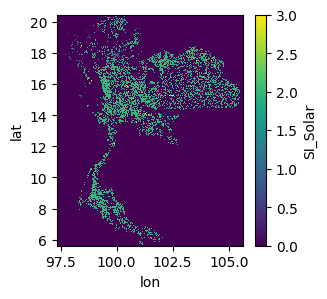

In [10]:
# STEP 8: Apply Transportation Network Buffer (Optimized)
# =========================================================
# Purpose: Exclude areas near roads that are unsuitable for RE development
# Buffer: 600m (2x the 300m pixel resolution) around all transportation routes

print('Loading transportation network...')
trans = gpd.read_file('Data\\trans\\Trans.shp')
trans.crs = {'init': 'epsg:4326'}
trans = trans.to_crs({'init': 'epsg:3857'})  # Project to meters for distance calculation

# Convert xarray back to GeoDataFrame (keep in Web Mercator for spatial operations)
df_landuse_suitability_index = xr_landuse_suitability_index.to_dataframe()
df_landuse_suitability_index.reset_index(inplace=True)
df_landuse_suitability_index = gpd.GeoDataFrame(
    df_landuse_suitability_index,
    geometry=gpd.points_from_xy(df_landuse_suitability_index['lon'], df_landuse_suitability_index['lat']),
    crs='EPSG:4326'
)
df_landuse_suitability_index = df_landuse_suitability_index.to_crs('EPSG:3857')

# Ensure dataframe has a clean RangeIndex for proper alignment
df_landuse_suitability_index = df_landuse_suitability_index.reset_index(drop=True)

# Find distance to nearest road for each data point (vectorized)
print('Computing distances to nearest road...')
sjoin_result = gpd.sjoin_nearest(
    df_landuse_suitability_index[['geometry']], 
    trans[['geometry']], 
    distance_col='distance', 
    how='left'
)

# Handle duplicate indices by keeping minimum distance per point
distances_series = sjoin_result.groupby(level=0)['distance'].min()

# Create mask: True for points closer than buffer distance (600m = 2x resolution)
# Explicitly match the length to the dataframe
too_close_to_road = distances_series.fillna(float('inf')).values
too_close_to_road = too_close_to_road <= (lccs_resolution * 2)

print(f'Points too close to roads (<600m): {too_close_to_road.sum()}')

# Reproject back to geographic coordinates
df_landuse_suitability_index = df_landuse_suitability_index.to_crs('EPSG:4326')

# Vectorized assignment: set all SI columns to 0 where mask is True
si_columns = ['lccs_class', 'SI_BGEC', 'SI_Biomass', 'SI_Solar', 'SI_Wind', 'SI_BGWW', 'SI_MSW', 'SI_IEW']
df_landuse_suitability_index.loc[too_close_to_road, si_columns] = 0

# Convert back to xarray
df_landuse_suitability_index = df_landuse_suitability_index.drop(columns='geometry')
df_landuse_suitability_index = df_landuse_suitability_index.set_index(['lat', 'lon'])
xr_landuse_suitability_index = xr.Dataset.from_dataframe(df_landuse_suitability_index)

print(xr_landuse_suitability_index)
fig, ax = plt.subplots(figsize=(3,3))
xr_landuse_suitability_index['SI_Solar'].plot(ax=ax, zorder=0)


### Visualization: After Transportation Filtering

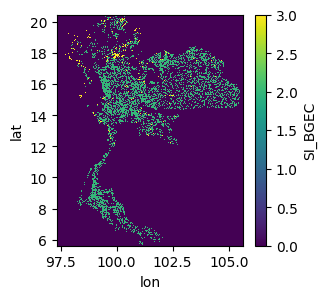

In [11]:
fig, ax = plt.subplots(figsize=(3,3))
xr_landuse_suitability_index['SI_BGEC'].plot(ax = ax,zorder = 0)

## Step 9: Apply Airport & Transmission Line Buffers

Exclude areas within buffer zones of airports and high-voltage transmission lines.

In [12]:
# STEP 9: Apply Airport & Transmission Line Buffers
# ==================================================
# Purpose: Exclude areas near airports and high-voltage transmission lines
# These areas have safety restrictions and electromagnetic interference concerns
# 
# Buffers applied:
#   - Airports: 0.05 degrees (≈ 5.5 km at equator) for safety distance
#   - Transmission lines: 0.01 degrees (≈ 1.1 km) for electromagnetic safety

print('Loading airport and transmission line data...')

# Load and buffer airport facilities
apa = gpd.read_file('Data\\thaairport2015\\THA_airport2015.shp')
apa.crs = {'init': 'epsg:4326'}
apa['geometry'] = apa['geometry'].buffer(0.05)  # 5.5 km safety buffer
print(f'Airports: {len(apa)}')

# Load and buffer transmission lines
transline = gpd.read_file('Data\\transmission_lines\\Transmission_linesLine.shp')
transline.crs = {'init': 'epsg:3857'}
transline = transline.to_crs({'init': 'epsg:4326'})  # Convert to WGS84
transline['geometry'] = transline['geometry'].buffer(0.01)  # 1.1 km safety buffer
print(f'Transmission line segments: {len(transline)}')

# Combine both restriction layers into single GeoDataFrame
restrictions = pd.concat([
    apa[['geometry']].assign(type='airport'),
    transline[['geometry']].assign(type='transmission')
], ignore_index=True)
restrictions = gpd.GeoDataFrame(restrictions, geometry='geometry', crs={'init': 'epsg:4326'})
print(f'Total restricted areas: {len(restrictions)}')

# Convert xarray back to GeoDataFrame
df_landuse_suitability_index = xr_landuse_suitability_index.to_dataframe()
df_landuse_suitability_index.reset_index(inplace=True)
df_landuse_suitability_index = gpd.GeoDataFrame(
    df_landuse_suitability_index,
    geometry=gpd.points_from_xy(df_landuse_suitability_index['lon'], df_landuse_suitability_index['lat']),
    crs='EPSG:4326'
)

# Spatial join: Find data points within restricted areas
print('Checking points against restricted areas...')
points_in_restrictions = gpd.sjoin(df_landuse_suitability_index, restrictions, how='left')

# Create mask: True for points inside airports or transmission buffers
# Use groupby to handle duplicate indices from sjoin
inside_restrictions = points_in_restrictions.index_right.notna().groupby(level=0).any().values

# Vectorized assignment: set all SI columns to 0 where mask is True
si_columns = ['lccs_class', 'SI_BGEC', 'SI_Biomass', 'SI_Solar', 'SI_Wind', 'SI_BGWW', 'SI_MSW', 'SI_IEW']
df_landuse_suitability_index.loc[inside_restrictions, si_columns] = 0

df_landuse_suitability_index = df_landuse_suitability_index.drop(columns='geometry')
df_landuse_suitability_index = df_landuse_suitability_index.set_index(['lat', 'lon'])
xr_landuse_suitability_index = xr.Dataset.from_dataframe(df_landuse_suitability_index)

print(xr_landuse_suitability_index)

Loading airport and transmission line data...
Airports: 50
Transmission line segments: 49
Total restricted areas: 99


d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\595078\AppData\Local\Temp\ipykernel_2268\2033977135.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  apa['geometry'] = apa['geometry'].buffer(0.05)  # 5.5 km safety buffer
d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyp

Checking points against restricted areas...


C:\Users\595078\AppData\Local\Temp\ipykernel_2268\2033977135.py:44: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: +init=epsg:4326 +type=crs

  points_in_restrictions = gpd.sjoin(df_landuse_suitability_index, restrictions, how='left')


<xarray.Dataset> Size: 463MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    lccs_class  (lat, lon) uint8 16MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


### Visualization: Final BGEC Suitability Index

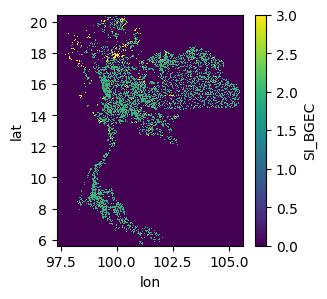

In [13]:
fig, ax = plt.subplots(figsize=(3,3))
xr_landuse_suitability_index['SI_BGEC'].plot(ax = ax,zorder = 0)

## Step 10: Export Pre-Feedstock Land Cover Results to NetCDF

Save the base land cover suitability dataset to NetCDF format for feedstock integration in `1.1_SI_Landcover_feedstock`.

In [14]:
xr_landuse_suitability_index.to_netcdf(path='Output\\xr_SI_Landcover_beforefeedstock.nc')

## Summary: Final Dataset

Display comprehensive information about the processed suitability index dataset.

In [15]:
print(xr_landuse_suitability_index)

<xarray.Dataset> Size: 463MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    lccs_class  (lat, lon) uint8 16MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0


### Final Visualization: MSW Suitability Index

Display the suitability map for Municipal Solid Waste (MSW) energy at full resolution.

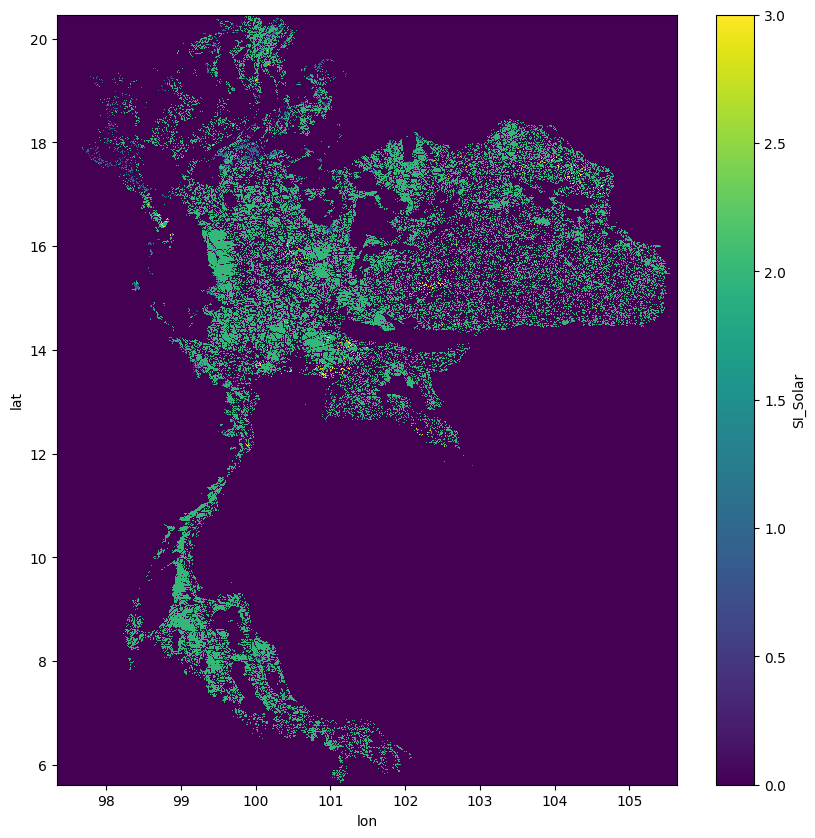

In [16]:
fig, ax = plt.subplots(figsize=(10,10))
xr_landuse_suitability_index['SI_Solar'].plot(ax = ax,zorder = 0)